In [1]:
!unzip -o "./Custom Workflow Instance Segmentation.v1i.yolov8.zip" -d yolo_dataset

Archive:  ./Custom Workflow Instance Segmentation.v1i.yolov8.zip
  inflating: yolo_dataset/README.dataset.txt  
  inflating: yolo_dataset/README.roboflow.txt  
  inflating: yolo_dataset/data.yaml  
 extracting: yolo_dataset/test/images/Oil_0005_jpg.rf.6e1675575fb81a231a00db2790012c6d.jpg  
 extracting: yolo_dataset/test/images/Oil_0038_jpg.rf.9602ea5f7046cbbd8a9ee5f43ba375bc.jpg  
 extracting: yolo_dataset/test/images/Oil_0044_jpg.rf.6bd79d687c2b079a29155c1aa82b9bf7.jpg  
 extracting: yolo_dataset/test/images/Oil_0050_jpg.rf.894cd85dc54eb2fe4ccdca3967817abe.jpg  
 extracting: yolo_dataset/test/images/Oil_0051_jpg.rf.7893264bb6b96b8ad16fddf3f28b0456.jpg  
 extracting: yolo_dataset/test/images/Oil_0052_jpg.rf.cf03447d2645720553353074790aedce.jpg  
 extracting: yolo_dataset/test/images/Oil_0072_jpg.rf.816fd2d68b2602b0ff469023b9fc635a.jpg  
 extracting: yolo_dataset/test/images/Oil_0104_jpg.rf.16f63232052de88c0ad446275dfc21f7.jpg  
 extracting: yolo_dataset/test/images/Oil_0111_jpg.rf.5162

In [2]:
!pip install ultralytics
from ultralytics import YOLO

# YOLOv8n 세그멘테이션 모델
model = YOLO('yolov8n-seg.pt')

# 학습 실행
model.train(
    data='./yolo_dataset/data.yaml',
    epochs=10,
    imgsz=640,
    batch=8,
    name='yolo_seg',
    task='segment'
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_seg, nbs=64, nms=False, opset

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c80d4c59f10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 


image 1/1 /content/yolo_dataset/test/images/Oil_0051_jpg.rf.7893264bb6b96b8ad16fddf3f28b0456.jpg: 640x640 1 --, 9.0ms
Speed: 1.9ms preprocess, 9.0ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/yolo_dataset/test/images/Oil_0115_jpg.rf.7e345b56bf1f523346717b4cc87fd935.jpg: 640x640 1 --, 9.0ms
Speed: 1.5ms preprocess, 9.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/yolo_dataset/test/images/Sta_0286_jpg.rf.22b31e070bb81c61f0771d2f33872e42.jpg: 640x640 6 --s, 9.0ms
Speed: 1.6ms preprocess, 9.0ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/yolo_dataset/test/images/Oil_0050_jpg.rf.894cd85dc54eb2fe4ccdca3967817abe.jpg: 640x640 3 --s, 15.6ms
Speed: 2.1ms preprocess, 15.6ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/yolo_dataset/test/images/Sta_0273_jpg.rf.0bd0f59e5451febf5e95e9544c7dc294.jpg: 640x640 1 --, 14.7ms
Speed: 2.6ms pre

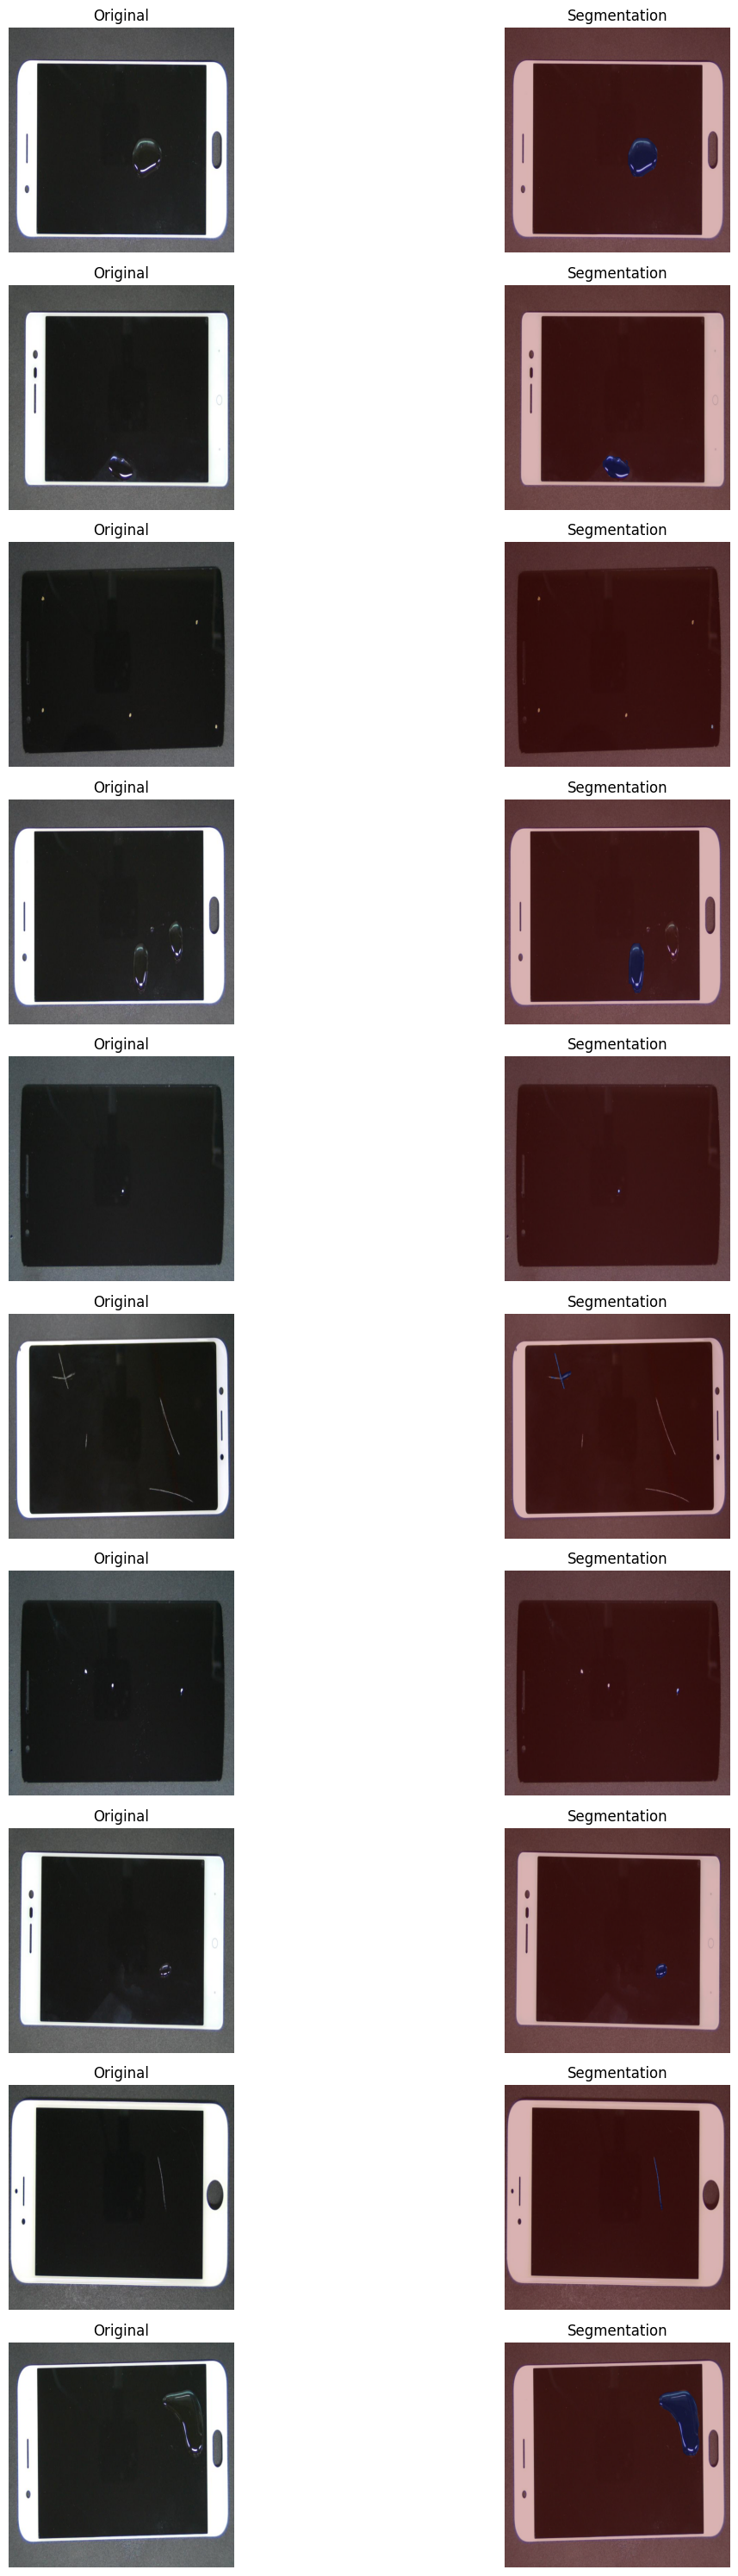

In [4]:
!pip install matplotlib opencv-python-headless ultralytics -q

import random, cv2, matplotlib.pyplot as plt
from ultralytics import YOLO
import glob
import numpy as np

# import glob
# images = sorted(glob.glob('./yolo_dataset/test/images/*.jpg'))
# print(f"Found {len(images)} test images")

# 모델 로드
model = YOLO('runs/segment/yolo_seg/weights/best.pt')

# 테스트 이미지 목록 준비
images = sorted(glob.glob('./yolo_dataset/test/images/*.jpg'))
sample_imgs = random.sample(images, k=min(10, len(images)))

plt.figure(figsize=(15, 30))

for i, img_path in enumerate(sample_imgs, 1):
    res = model.predict(source=img_path, imgsz=640)[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(10, 2, 2*i-1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Original')

    # 마스크가 없을 수도 있음
    if res.masks is not None and res.masks.data is not None:
        mask = (res.masks.data[0].cpu().numpy() * 255).astype('uint8')
        color_mask = cv2.applyColorMap(mask, cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(img, 0.7, color_mask, 0.3, 0)

        plt.subplot(10, 2, 2*i)
        plt.imshow(overlay)
        plt.axis('off')
        plt.title('Segmentation')
    else:
        plt.subplot(10, 2, 2*i)
        plt.text(0.5, 0.5, "No Segmentation", ha='center', va='center', fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()
